<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Cancer-Subtype-Classification-via-Genomic-Profiling/blob/main/Cancer_Subtype_Classification_via_Genomic_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

# Load both files
df_data = pd.read_csv('data.csv')
df_labels = pd.read_csv('labels.csv')

# Merge them
# Assuming the labels are in a single column in the labels file,
# we concatenate them or merge them on the index if they are already aligned.
df = pd.concat([df_data, df_labels.iloc[:, 1]], axis=1)

# Rename the label column to 'target' for clarity
df = df.rename(columns={df.columns[-1]: 'target'})

In [10]:
# Separate features (X) and target (y)
X = df.drop(['Unnamed: 0', 'target'], axis=1) # Drop non-feature columns
y = df['target']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Check how many missing values you have in your features
print("Missing values in X:", X.isnull().sum().sum())

# Strategy 1: Fill missing values with the mean of that column
X = X.fillna(X.mean())

# Strategy 2 (Alternative): Drop any rows that have missing values
# X = X.dropna()
# (You must also drop the corresponding rows in y if you use this method)

# After cleaning, confirm no NaNs remain
print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values in X: 17785
Missing values after cleaning: 0


In [14]:
# 1. Create a combined DataFrame temporarily to drop rows that have NaNs in either X or y
df_clean = df.dropna()

# 2. Now redefine X and y from the cleaned dataframe
X = df_clean.drop(['Unnamed: 0', 'target'], axis=1)
y = df_clean['target']

# 3. Now re-split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Confirm they are clean and aligned
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("NaNs in y_train:", y_train.isnull().sum())

# 5. Now train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
print("Model trained successfully!")

X_train shape: (640, 20531), y_train shape: (640,)
NaNs in y_train: 0
Model trained successfully!


In [15]:
from sklearn.metrics import classification_report

# Predict on the test set
y_pred = clf.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        61
        COAD       1.00      1.00      1.00        17
        KIRC       1.00      1.00      1.00        25
        LUAD       1.00      1.00      1.00        29
        PRAD       1.00      1.00      1.00        29

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



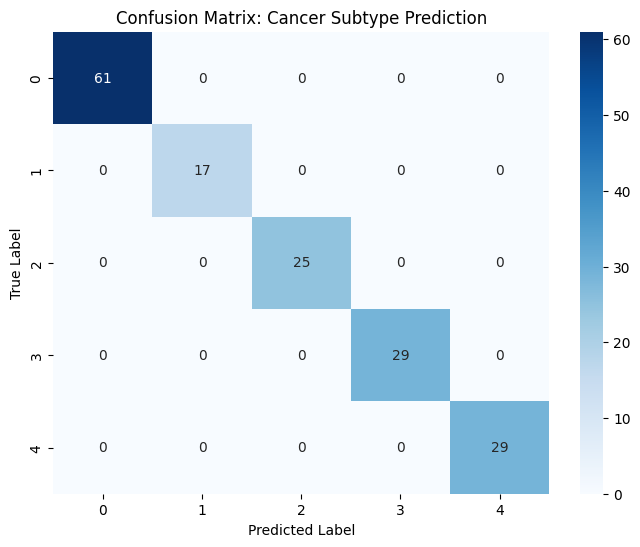

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Cancer Subtype Prediction')
plt.show()

In [17]:
# Create a dataframe to view top genes
feature_importances = pd.DataFrame(clf.feature_importances_,
                                   index=X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

# Display the top 10 most influential genes
print("Top 10 Biomarker Genes:")
print(feature_importances.head(10))

Top 10 Biomarker Genes:
            importance
gene_7896     0.011585
gene_15987    0.010972
gene_14068    0.009720
gene_6530     0.009040
gene_16358    0.008935
gene_7964     0.008574
gene_5598     0.008194
gene_15896    0.007832
gene_223      0.006581
gene_6816     0.006108


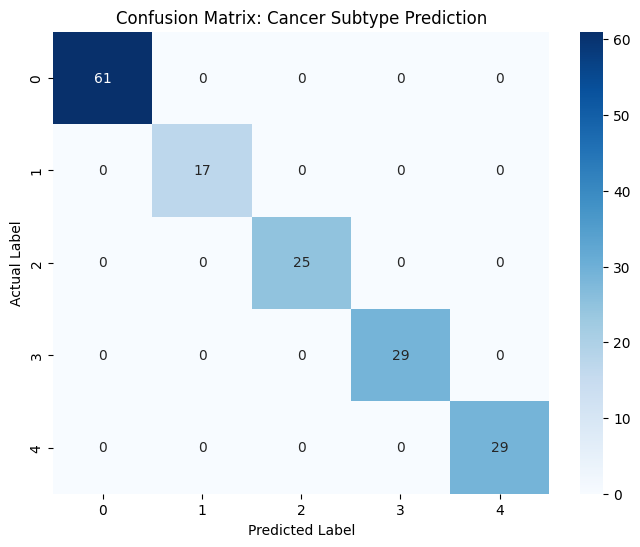

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Cancer Subtype Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

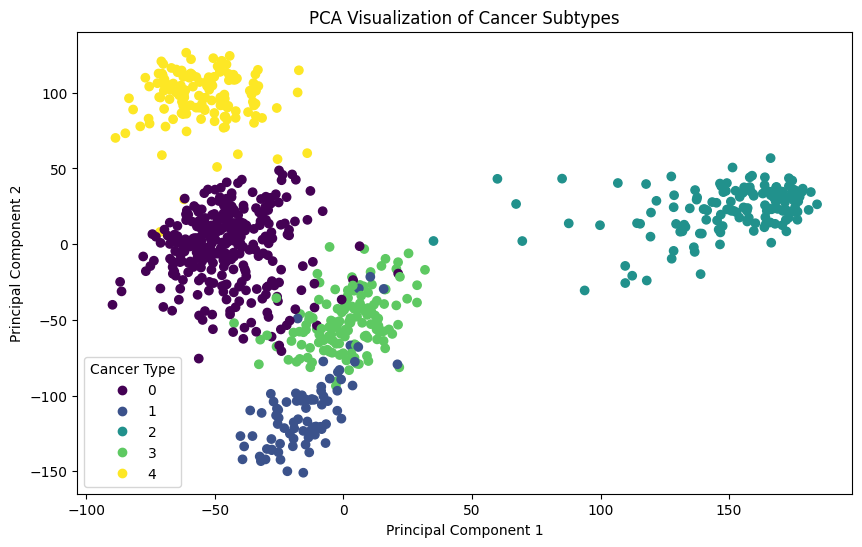

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Plot the results
plt.figure(figsize=(10, 6))
# Assume y is your target labels
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.astype('category').cat.codes, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Cancer Subtypes')
plt.legend(*scatter.legend_elements(), title="Cancer Type")
plt.show()